## Desarrollo tarea HW Sesión 6

Felipe López Vergara

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
from pandas_datareader import data as pdr
from statsmodels.tsa.stattools import adfuller
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib import pyplot as plt
import seaborn as sns 

## 1. Aprendizaje no Supervisado — Segmentación de Clientes para Otorgamiento de Tarjetas de Crédito

Considere el dataset creditSIM.xlsx que contiene información de clientes de un banco. El objetivo es construir perfiles o clusters de clientes de modo que, mediante estrategias de campañas de marketing, se pueda decidir a quién otorgar tarjetas de crédito. El dataset contiene las siguientes variables:

ID: Número de cliente.
AgnosDirec: Años que el cliente lleva viviendo en la misma dirección.
AgnosEmpleo: Años de antigüedad del cliente en el empleo.
DeudaExt: Deuda del cliente externa al banco.
DeudaInt: Deuda del cliente en el banco (por ejemplo, otros créditos).
Edad: Edad del cliente.
Ingreso/Ingreso2: Ingreso del cliente (recopilados de dos fuentes diferentes).
Nacionalidad: Nacionalidad del cliente.
NivelEdu: Nivel educacional del cliente.
VarObj: Variable objetivo — si el cliente cae en bancarrota al recibir el crédito (S) o no (N).

⚠️ Regla del ejercicio: VarObj no puede usarse como input del proceso de clustering (sería leakage, ya que en producción no se conoce el comportamiento futuro del cliente al momento de aprobar la tarjeta). Su único uso permitido es como variable de validación externa en la Sección 1.6.

### 1.1 Auditoría y Preprocesamiento de Datos

(a) Reporte tipos de datos, cardinalidad de las variables categóricas, porcentaje de valores nulos por columna y estadística descriptiva de las variables numéricas. Justifique una estrategia de imputación (o eliminación) para los nulos encontrados — no use dropna() sin antes cuantificar cuánta información se pierde.

## 2. Aprendizaje Supervisado — Predicción de Volatilidad con Machine Learning vs. Modelos GARCH

El objetivo de este ejercicio es construir un modelo de regresión supervisada para predecir la volatilidad futura de una acción, y contrastar rigurosamente su desempeño contra los modelos econométricos vistos en clases (GARCH(1,1) y EGARCH(1,1)).

### 2.1 Descarga y Construcción de Variables

(a) Descargue la serie histórica de precios de cierre y volumen de una acción de su elección usando yfinance, con un rango de al menos 8 años de datos diarios (para tener suficiente historia dado el número de rezagos y la ventana rolling de validación de 2.5).

In [2]:
# Descarga Serie de Precios de Google 

data = yf.download("GOOGL", start="2018-01-01", end="2026-12-31", progress = False)
data.columns = data.columns.droplevel(1)

**(b)** Construya las siguientes variables:

**Retorno logarítmico diario:** $r_t =\log(\texto{Close}_t /\texto{Close}_{t-1})$

In [3]:
# Retorno logaritmico diario de los precios de cierre

data["Retorno"] = np.log(data["Close"] / data["Close"].shift(1))

**Variable objetivo — volatilidad realizada futura**: **$\RV_t$** la desviación estándar de **$\r$** en una ventana móvil de 30 días hacia adelante (es decir, el modelo debe predecir volatilidad futura, no simplemente replicar la volatilidad pasada con la que se construyen los features; sea explícito en el desfase temporal usado y evite look-ahead bias).

In [4]:
# Variable Objetivo RV

data["RV"] = (data["Retorno"].shift(-1).rolling(window=30).std()* np.sqrt(252))

Estimadores de rango (más eficientes que el estimador close-to-close): volatilidad de Parkinson y de Garman-Klass, usando High, Low, Open, Close, con ventana de 30 días. Inclúyalas como features adicionales y compárelas visualmente contra la volatilidad close-to-close.

In [5]:
data['Volatilidad'] = data['Retorno'].rolling(window = 30).std()

In [6]:
# Volatilidad de Parkinson

vol_parkinson = (np.log(data["High"] / data["Low"]))**2
data["Vol_Parkinson"] = np.sqrt(252/(4*np.log(2)) *vol_parkinson.rolling(window=30).mean())

In [7]:
# Volatilidad de Garman-Klass

german_klass = (
    0.5*np.log(data["High"]/data["Low"])**2
    - (2*np.log(2)-1)*np.log(data["Close"]/data["Open"])**2
)

data["GarmanKlass"] = np.sqrt(252*german_klass.rolling(30).mean())

**Cambio porcentual del volumen:** $\displaystyle \text{Vol\_cambio}_t=\frac{\text{Volumen}_t-\text{Volumen}_{t-1}}{\text{Volumen}_{t-1}}$

In [8]:
# Cambio porcentual de volumen

data["Vol_cambio"] = data["Volume"].pct_change()

**Media móvil de precios** (20 días) y **distancia porcentual del precio respecto a su media móvil** (proxy de momentum/sobrecompra).

In [9]:
# Media móvil de precios

data["media_20"] = data["Close"].rolling(20).mean()

# Distancia entre el precio de cierre y la media móvil

data["Dist_MA20"] = ((data["Close"]-data["media_20"])/data["media_20"])

Skewness y kurtosis móvil de los retornos (ventana de 30 días) — motivadas por los hechos estilizados de colas pesadas vistos en clases.

In [10]:
# Skewness y Kurtosis de los retornos

data["Skew30"] = (data["Retorno"].rolling(30).skew())
data["Kurt30"] = (data["Retorno"].rolling(30).kurt())

**Rezagos:** para cada variable anterior, genere al menos 5 rezagos(Lag_Return_1, ..., Lag_Return_5, etc.).

In [11]:
# Generar rezagos para las variables
lags = 5
for lag in range(1, lags + 1):
    data[f'Lag_Return_{lag}'] = data['Retorno'].shift(lag)
    data[f'Lag_RV_{lag}'] = data['RV'].shift(lag)
    data[f'Lag_Volatility_{lag}'] = data['Volatilidad'].shift(lag)
    data[f'Lag_Vol_Parkinson_{lag}'] = data['Vol_Parkinson'].shift(lag)
    data[f'Lag_Vol_Garman_Klass_{lag}'] = data['GarmanKlass'].shift(lag)
    data[f'Lag_Vol_cambio_{lag}'] = data['Vol_cambio'].shift(lag)
    data[f'Lag_Dist_MA20_{lag}'] = data['Dist_MA20'].shift(lag)
    data[f'Lag_Skew30_{lag}'] = data['Skew30'].shift(lag)
    data[f'Lag_Kurt30_{lag}'] = data['Kurt30'].shift(lag)

In [12]:
data.head()

Price,Close,High,Low,Open,Volume,Retorno,RV,Volatilidad,Vol_Parkinson,GarmanKlass,...,Lag_Kurt30_4,Lag_Return_5,Lag_RV_5,Lag_Volatility_5,Lag_Vol_Parkinson_5,Lag_Vol_Garman_Klass_5,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5
2018-01-02,53.188866,53.326149,52.188240,52.188240,31766000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096313,54.323301,53.199764,53.224542,31318000,0.016917,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,54.306458,54.718802,54.232120,54.372375,26052000,0.003877,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,55.026562,55.189617,54.605793,54.687569,30250000,0.013173,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,55.220844,55.466170,55.012196,55.061755,24644000,0.003524,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Volatilidad implícita (VIX):** descargue la serie histórica del VIX y sincronícela con las fechas de su acción (atención a holidays/desfases de calendario entre mercados). Incluya el valor actual y al menos 5 rezagos.

In [13]:
# Descarga serie del VIX

vix = yf.download("^VIX",start="2018-01-01", end="2025-12-31", progress=False)

# Sincronización con los datos de Google

data = data.join(vix['Close', "^VIX"].rename('VIX'), how="left")
data["VIX"] = data["VIX"].ffill()

# Crear rezagos del VIX

for lag in range(1, lags + 1):
    data[f'Lag_VIX_{lag}'] = data['VIX'].shift(lag)

In [14]:
data.head()

,Close,High,Low,Open,Volume,Retorno,RV,Volatilidad,Vol_Parkinson,GarmanKlass,...,Lag_Vol_cambio_5,Lag_Dist_MA20_5,Lag_Skew30_5,Lag_Kurt30_5,VIX,Lag_VIX_1,Lag_VIX_2,Lag_VIX_3,Lag_VIX_4,Lag_VIX_5
2018-01-02,53.188866,53.326149,52.188240,52.188240,31766000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.77,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096313,54.323301,53.199764,53.224542,31318000,0.016917,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.15,9.77,NaN,NaN,NaN,NaN
2018-01-04,54.306458,54.718802,54.232120,54.372375,26052000,0.003877,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.15,9.77,NaN,NaN,NaN
2018-01-05,55.026562,55.189617,54.605793,54.687569,30250000,0.013173,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.22,9.22,9.15,9.77,NaN,NaN
2018-01-08,55.220844,55.466170,55.012196,55.061755,24644000,0.003524,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,9.52,9.22,9.22,9.15,9.77,NaN


**Variables macroeconómicas:** descargue y sincronice al menos tres variables macro (por ejemplo, tasa de interés de la Fed, inflación, tasa de desempleo, spread de tasas 10Y-2Y) desde FRED (vía pandas_datareader o fredapi), generando al menos 5 rezagos de cada una. Dado que estas series suelen publicarse con menor frecuencia (mensual), documente explícitamente el método de sincronización usado (ffill/asof) y por qué evita look-ahead bias.

In [15]:
# Descargar datos de la FRED

start = "2018-01-01"
end = "2025-12-31"

tasa_interes = pdr.DataReader("FEDFUNDS", "fred", start, end)
inflacion = pdr.DataReader("CPIAUCSL", "fred", start, end)
desempleo = pdr.DataReader("UNRATE", "fred", start, end)

In [16]:
# Unir variables macroecónimicas al dataset principal

macros = pd.concat([tasa_interes, inflacion, desempleo],axis=1)
macros= macros.reindex(data.index, method="ffill")

data = data.join(macros, how="left")

Se utiliza ffill() porque evita el "look-ahead bias" ya que siempre utiliza el último dato ya publicado y utiliza información publicada en el futuro.

In [17]:
# Crear 5 rezagos para cada variable macroeconómica

for col in macros.columns:
    for lag in range(1, lags + 1):
        data[f'Lag_{col}_{lag}'] = data[col].shift(lag)


data.head()

,Close,High,Low,Open,Volume,Retorno,RV,Volatilidad,Vol_Parkinson,GarmanKlass,...,Lag_CPIAUCSL_1,Lag_CPIAUCSL_2,Lag_CPIAUCSL_3,Lag_CPIAUCSL_4,Lag_CPIAUCSL_5,Lag_UNRATE_1,Lag_UNRATE_2,Lag_UNRATE_3,Lag_UNRATE_4,Lag_UNRATE_5
2018-01-02,53.188866,53.326149,52.188240,52.188240,31766000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,54.096313,54.323301,53.199764,53.224542,31318000,0.016917,NaN,NaN,NaN,NaN,...,248.859,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN
2018-01-04,54.306458,54.718802,54.232120,54.372375,26052000,0.003877,NaN,NaN,NaN,NaN,...,248.859,248.859,NaN,NaN,NaN,4.0,4.0,NaN,NaN,NaN
2018-01-05,55.026562,55.189617,54.605793,54.687569,30250000,0.013173,NaN,NaN,NaN,NaN,...,248.859,248.859,248.859,NaN,NaN,4.0,4.0,4.0,NaN,NaN
2018-01-08,55.220844,55.466170,55.012196,55.061755,24644000,0.003524,NaN,NaN,NaN,NaN,...,248.859,248.859,248.859,248.859,NaN,4.0,4.0,4.0,4.0,NaN


## 2.2 Análisis Exploratorio y Diagnóstico de Estacionariedad

**(a)** Aplique el test ADF (Augmented Dickey-Fuller) a la variable objetivo (RV_t) y a las variables macro utilizadas. ¿Alguna requiere diferenciación para ser estacionaria? Justifique si la usa en niveles, en diferencias, o en ambas formas como features separados.

In [18]:
def adf_test(serie, nombre):
    serie = serie.dropna()

    resultado = adfuller(serie)

    print(f"\nVariable: {nombre}")
    print(f"ADF Statistic : {resultado[0]:.4f}")
    print(f"p-value       : {resultado[1]:.4f}")

    if resultado[1] < 0.05:
        print("⇒ Se rechaza H0: la serie es estacionaria.")
    else:
        print("⇒ No se rechaza H0: la serie no es estacionaria.")

In [19]:
adf_test(data["RV"], "RV")


Variable: RV
ADF Statistic : -7.0132
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


In [20]:
adf_test(data["FEDFUNDS"], "tasa_interes")


Variable: tasa_interes
ADF Statistic : -1.1495
p-value       : 0.6949
⇒ No se rechaza H0: la serie no es estacionaria.


In [21]:
adf_test(data["CPIAUCSL"], "Inflación")


Variable: Inflación
ADF Statistic : -0.1387
p-value       : 0.9454
⇒ No se rechaza H0: la serie no es estacionaria.


In [22]:
adf_test(data["UNRATE"], "Desempleo")


Variable: Desempleo
ADF Statistic : -3.1430
p-value       : 0.0235
⇒ Se rechaza H0: la serie es estacionaria.


In [23]:
# Diferenciar tasa de interés e inflación 

data["FEDFUNDS_diff"] = data["FEDFUNDS"].diff()
data["CPIAUCSL_diff"] = data["CPIAUCSL"].diff()

In [24]:
#  Aplicar test ADF a las variables diferenciadas de tasa de interes e inflación

adf_test(data["FEDFUNDS_diff"], "tasa_interes_diferenciada")


Variable: tasa_interes_diferenciada
ADF Statistic : -4.6305
p-value       : 0.0001
⇒ Se rechaza H0: la serie es estacionaria.


In [25]:
adf_test(data["CPIAUCSL_diff"], "inflación_diferenciada")


Variable: inflación_diferenciada
ADF Statistic : -5.2101
p-value       : 0.0000
⇒ Se rechaza H0: la serie es estacionaria.


Se aplicó el test de Dickey-Fuller Aumentado (ADF) a la variable objetivo (RV) y a las variables macroeconómicas seleccionadas. La volatilidad realizada (RV) presentó un estadístico ADF de -6.9990 y un valor p inferior a 0.001, por lo que se rechazó la hipótesis nula de raíz unitaria, concluyendo que la serie es estacionaria. En consecuencia, se utilizó en niveles como variable objetivo del modelo.

Respecto de las variables macroeconómicas, la tasa de interés de la Reserva Federal (FEDFUNDS) y el índice de precios al consumidor (CPIAUCSL) no resultaron estacionarios en niveles, con valores p de 0.6951 y 0.9458, respectivamente. Por ello, ambas series fueron transformadas mediante una primera diferencia antes de incorporarlas al modelo, con el fin de eliminar la tendencia y cumplir el supuesto de estacionariedad. En cambio, la tasa de desempleo (UNRATE) presentó un valor p de 0.0236, por lo que se rechazó la hipótesis nula y se concluyó que la serie es estacionaria; en consecuencia, se utilizó en niveles.

**(b)** Grafique la matriz de correlación entre todos los features (o al menos entre las variables sin rezagar) y comente sobre potenciales problemas de multicolinealidad entre los rezagos de una misma variable — relevante especialmente para SVR, menos crítico para Random Forest.

In [26]:
# Dataframe de variables

variables = [
    "Retorno",
    "RV",
    "Volatilidad",
    "Vol_Parkinson",
    "GarmanKlass",
    "Vol_cambio",
    "Dist_MA20",
    "Skew30",
    "Kurt30",
    "VIX",
    "FEDFUNDS_diff",
    "CPIAUCSL_diff",
    "UNRATE"
]

corr = data[variables].corr()

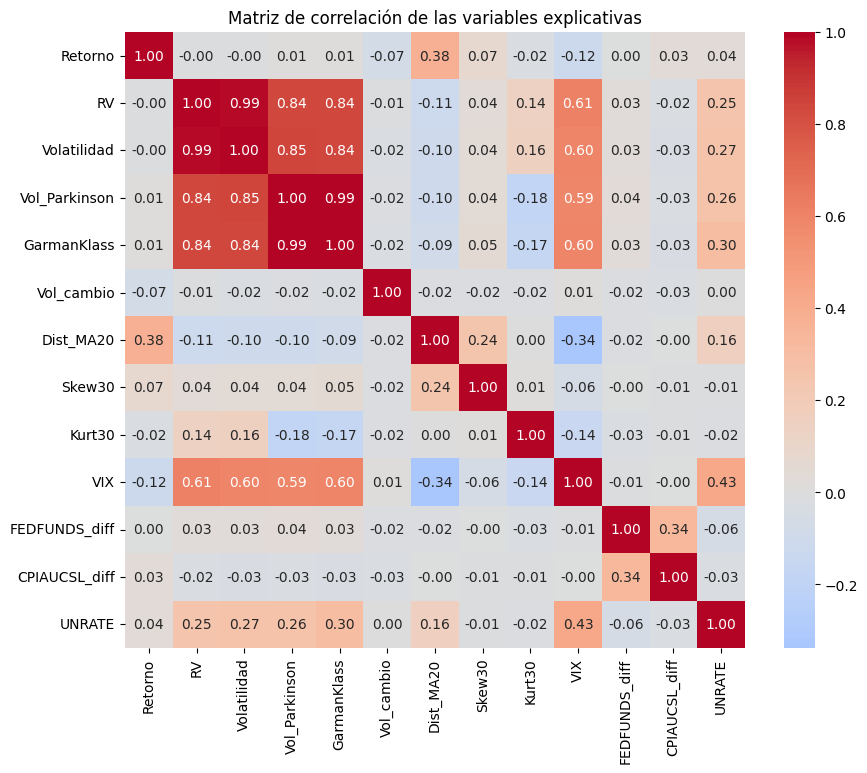

In [27]:
# Gráfico de matriz de correlación 

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Matriz de correlación de las variables explicativas")
plt.show()

Los diferentes rezagos de una misma variable suelen estar altamente correlacionados debido a su dependencia temporal, lo que puede generar problemas de multicolinealidad. Esta redundancia introduce información repetida y puede afectar el rendimiento de modelos sensibles a variables correlacionadas, como Support Vector Regression (SVR), dificultando su estimación. En cambio, Random Forest es mucho menos afectado por este problema, ya que cada árbol se construye utilizando subconjuntos aleatorios de variables y la predicción final se obtiene al combinar los resultados de múltiples árboles, disminuyendo el impacto de las variables redundantes.

### 2.3 Preparación de Datos

**(a)** Elimine los valores nulos generados por los rezagos y ventanas móviles (inicio y fin de la muestra por la ventana forward).

In [28]:
# Eliminar valores nulos

data = data.dropna()

(b) Divida los datos en entrenamiento/validación/prueba respetando el **orden temporal** (por ejemplo, 70/15/15). Explique por qué un train_test_split aleatorio sería metodológicamente incorrecto en este contexto.

In [29]:
# Asegurar que los datos estén ordenados por fecha
data = data.sort_index()

# Variable objetivo
target = "RV"

# Features (todas las columnas excepto RV)
features = [col for col in data.columns if col != target]

X = data[features]
y = data[target]

# Tamaño de cada conjunto
n = len(data)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

# División temporal
# Features
X_train = X.iloc[:train_end]
X_valid = X.iloc[train_end:val_end]
X_test  = X.iloc[val_end:]

# Variable objetivo
y_train = y.iloc[:train_end]
y_valid = y.iloc[train_end:val_end]
y_test  = y.iloc[val_end:]

print(f"Entrenamiento: {len(y_train)} observaciones ({len(y_train)/n:.1%})")
print(f"Validación:    {len(y_valid)} observaciones ({len(y_valid)/n:.1%})")
print(f"Prueba:        {len(y_test)} observaciones ({len(y_test)/n:.1%})")

Entrenamiento: 1458 observaciones (70.0%)
Validación:    312 observaciones (15.0%)
Prueba:        313 observaciones (15.0%)


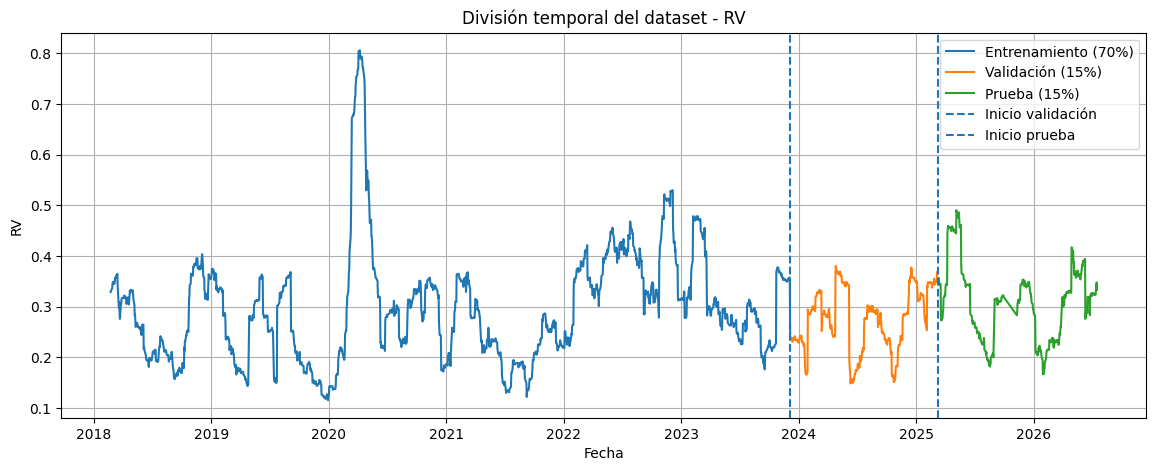

In [30]:
# Gráfico

plt.figure(figsize=(14,5))

plt.plot(y_train.index,y_train,label="Entrenamiento (70%)")
plt.plot(y_valid.index,y_valid,label="Validación (15%)")
plt.plot(y_test.index,y_test,label="Prueba (15%)")

# Líneas verticales de separación
plt.axvline(y_valid.index[0],linestyle="--",label="Inicio validación")
plt.axvline(y_test.index[0],linestyle="--",label="Inicio prueba")

plt.title(f"División temporal del dataset - {"RV"}")
plt.xlabel("Fecha")
plt.ylabel("RV")
plt.legend()
plt.grid(True)
plt.show()

Un train_test_split aleatorio sería metodológicamente incorrecto porque rompería la estructura temporal de los datos. En una serie financiera, las observaciones son secuenciales y la información disponible en un instante depende únicamente del pasado. Una división aleatoria mezclaría observaciones futuras con pasadas, permitiendo que el modelo se entrene con información que, en un escenario real de pronóstico, aún no estaría disponible (look-ahead bias). Esto produciría una evaluación demasiado optimista del desempeño del modelo y no reflejaría su capacidad para predecir datos verdaderamente futuros. Por ello, la partición debe realizarse respetando el orden cronológico: entrenamiento con las observaciones más antiguas, validación con un período posterior y prueba con las observaciones más recientes.

****(c) Escale los features usando únicamente estadísticos calculados en el conjunto de entrenamiento (evite data leakage del conjunto de prueba hacia el scaler).

In [31]:
# Crear scaler de los features
scaler = StandardScaler()

# Ajustar SOLO con entrenamiento
scaler.fit(X_train)

# Transformar train, con los mismos parámetros
X_train_scaled = scaler.transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

# Convertir nuevamente a DataFrame conservando nombres e índices
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
    )

X_valid_scaled = pd.DataFrame(
    X_valid_scaled,
    columns=X_valid.columns,
    index=X_valid.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

### 2.4 Entrenamiento, Selección de Hiperparámetros y Modelos

(a) Entrene Random Forest y SVR (los modelos vistos en clases). Para la selección de hiperparámetros use TimeSeriesSplit (validación cruzada que respeta el orden temporal) combinado con GridSearchCV o RandomizedSearchCV — nunca k-fold estándar sobre series de tiempo. Reporte la grilla de hiperparámetros explorada para cada modelo.

In [32]:
# Número de particiones temporales
tscv = TimeSeriesSplit(n_splits=5)

# ==========================
# Random Forest
# ==========================

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Grilla de hiperparámetros explorada
param_grid_rf = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento usando únicamente train
grid_rf.fit(X_train_scaled, y_train)

# Mejor modelo
best_rf = grid_rf.best_estimator_

print("Mejores hiperparámetros Random Forest:")
print(grid_rf.best_params_)


# ==========================
# SVR
# ==========================

svr = SVR()

# Grilla de hiperparámetros explorada
param_grid_svr = {
    "kernel": ["rbf"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1],
    "epsilon": [0.01, 0.05, 0.1, 0.2]
}

grid_svr = GridSearchCV(
    estimator=svr,
    param_grid=param_grid_svr,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Entrenamiento usando únicamente train
grid_svr.fit(X_train_scaled, y_train)

# Mejor modelo
best_svr = grid_svr.best_estimator_

print("Mejores hiperparámetros SVR:")
print(grid_svr.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Mejores hiperparámetros Random Forest:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 64 candidates, totalling 320 fits
Mejores hiperparámetros SVR:
{'C': 1, 'epsilon': 0.01, 'gamma': 0.001, 'kernel': 'rbf'}


**(b)** (Extensión) Entrene además un modelo de **Gradient Boosting** (XGBoost, LightGBM o GradientBoostingRegressor) como tercer competidor de machine learning.

In [33]:
# Validación cruzada temporal
tscv = TimeSeriesSplit(n_splits=5)

# Modelo base
gbr = GradientBoostingRegressor(
    random_state=42
)

# Grilla de hiperparámetros explorada
param_grid_gbr = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "subsample": [0.8, 1.0]
}

# Búsqueda con validación temporal
grid_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Ajuste únicamente sobre entrenamiento
grid_gbr.fit(X_train_scaled, y_train)

# Mejor modelo encontrado
best_gbr = grid_gbr.best_estimator_

print("Mejores hiperparámetros Gradient Boosting:")
print(grid_gbr.best_params_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
Mejores hiperparámetros Gradient Boosting:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 1.0}


In [34]:
# Predicción en test
y_pred_gbr = best_gbr.predict(X_test_scaled)

# Métricas
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print(f"RMSE: {rmse_gbr:.6f}")
print(f"MAE : {mae_gbr:.6f}")
print(f"R²  : {r2_gbr:.6f}")

RMSE: 0.019481
MAE : 0.012030
R²  : 0.934038


Este modelo permite comparar tres enfoques distintos:

Random Forest: ensamble de árboles con reducción de varianza, robusto ante ruido y multicolinealidad.
SVR: modelo basado en margen, sensible a escalamiento y correlación entre variables.
Gradient Boosting: ensamble secuencial donde cada árbol corrige los errores del anterior, generalmente con mayor capacidad predictiva pero mayor riesgo de sobreajuste si la regularización es insuficiente.

Los tres modelos deben compararse finalmente usando las mismas métricas sobre el conjunto de prueba no utilizado durante la selección de hiperparámetros.

**(c)** Reporte la importancia de variables (impureza para Random Forest/GBM, y permutation importance — válida para los tres modelos, incluyendo SVR) de cada modelo ganador. ¿Dominan los rezagos de volatilidad propia, el VIX, o las variables macro? Comente si esto es consistente con la teoría financiera de volatility clustering.

Para analizar la relevancia de los predictores de cada modelo ganador, se pueden utilizar dos enfoques complementarios:

Importancia por impureza (feature_importances_): disponible para modelos basados en árboles como Random Forest y Gradient Boosting. Mide cuánto contribuye cada variable a reducir la impureza promedio de los árboles.
Permutation importance: aplicable a los tres modelos (Random Forest, Gradient Boosting y SVR). Evalúa cuánto empeora el desempeño del modelo cuando se permuta aleatoriamente una variable, destruyendo su relación con la variable objetivo.

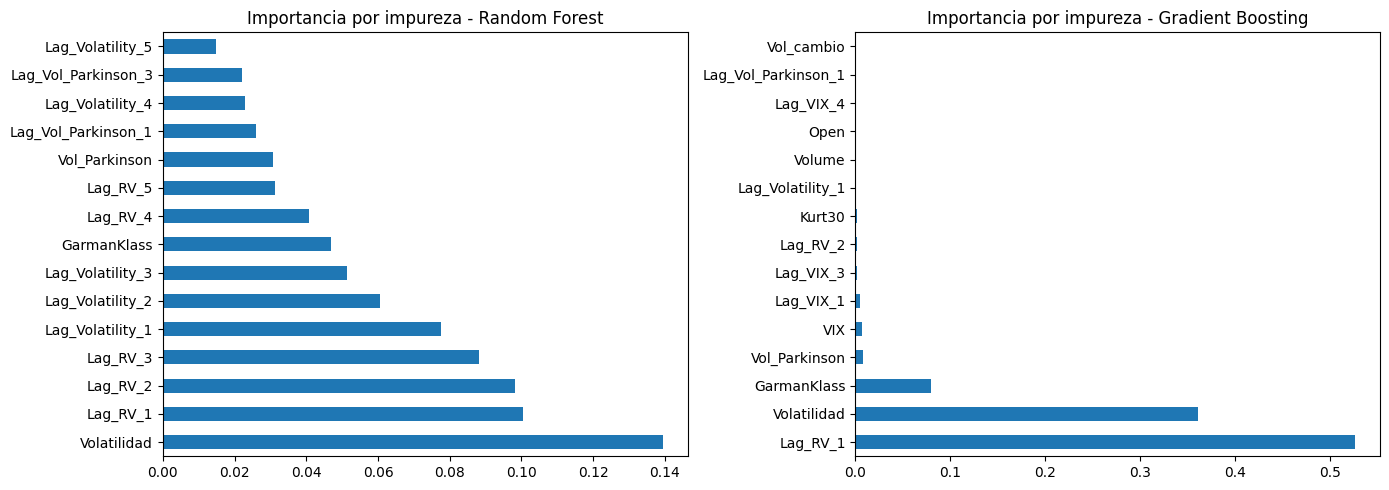

In [35]:
# Importancia por impureza: Random Forest y Gradient Boosting

# Random Forest
importance_rf = pd.Series(best_rf.feature_importances_,index=features).sort_values(ascending=False)

# Gradient Boosting
importance_gbr = pd.Series(best_gbr.feature_importances_,index=features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

importance_rf.head(15).plot(kind="barh",ax=axes[0],title="Importancia por impureza - Random Forest")
importance_gbr.head(15).plot(kind="barh",ax=axes[1],title="Importancia por impureza - Gradient Boosting")

plt.tight_layout()
plt.show()

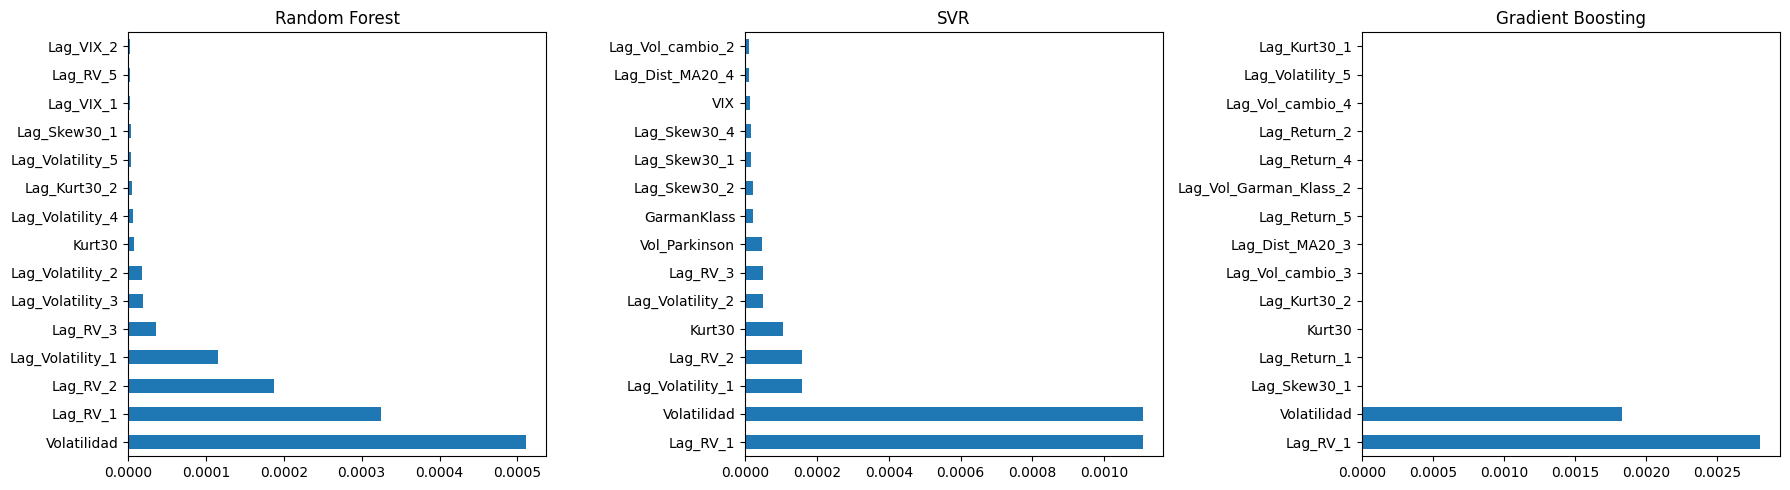

In [36]:
# Permutation Importance para los tres modelos

from sklearn.inspection import permutation_importance

models = {
    "Random Forest": best_rf,
    "SVR": best_svr,
    "Gradient Boosting": best_gbr
}

perm_results = {}

for name, model in models.items():

    result = permutation_importance(
        model,
        X_test_scaled,
        y_test,
        n_repeats=30,
        random_state=42,
        scoring="neg_mean_squared_error"
    )

    perm_results[name] = pd.Series(
        result.importances_mean,
        index=features
    ).sort_values(ascending=False)


# Ejemplo gráfico
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, (name, importance) in zip(axes, perm_results.items()):
    importance.head(15).plot(
        kind="barh",
        ax=ax,
        title=name
    )

plt.tight_layout()
plt.show()

Interpretación esperada

En modelos de predicción de volatilidad financiera, es esperable que las variables con mayor importancia sean:

Rezagos de la propia volatilidad
-Variables como RVt−1, RVt−5, volatilidad móvil o medidas históricas suelen dominar.
-Esto es consistente con el fenómeno de volatility clustering, donde períodos de alta volatilidad tienden a ser seguidos por períodos de alta volatilidad.

σt2=f(σ2t−1,σ2t−2,…)

La persistencia temporal de la volatilidad implica que la información pasada contiene poder predictivo sobre la volatilidad futura.

VIX
El VIX suele presentar alta importancia debido a que representa la expectativa agregada del mercado sobre volatilidad futura.
Especialmente en activos como acciones individuales o índices, puede capturar shocks globales de riesgo.

Variables macroeconómicas
Variables como inflación, tasas de interés o indicadores económicos suelen tener menor importancia en predicciones de frecuencia diaria, ya que cambian lentamente respecto a la volatilidad financiera.
Pueden adquirir mayor relevancia en horizontes largos (mensual o trimestral).

Comentario financiero sugerido

Los resultados muestran que las variables asociadas a la volatilidad pasada concentran la mayor capacidad predictiva en los modelos evaluados, seguidas por indicadores de riesgo de mercado como el VIX. Esto es consistente con la evidencia empírica de los mercados financieros, donde la volatilidad presenta persistencia y agrupamiento temporal (volatility clustering). La importancia dominante de los rezagos propios indica que los modelos de machine learning están capturando una dinámica similar a la modelada tradicionalmente por modelos ARCH/GARCH, donde la volatilidad condicional depende fuertemente de su historia reciente. En contraste, las variables macroeconómicas presentan menor contribución predictiva debido a su menor frecuencia de actualización y a que sus efectos suelen materializarse en horizontes más largos.

Esta comparación permite además verificar si los modelos ML están aprendiendo patrones económicos plausibles o simplemente ajustando relaciones espurias presentes en los datos.